# Hotel Booking Cancellation Prediction ML Project

This project titled "Hotel Booking Cancellation Prediction Machine Learning Project" is largely about studying hotel booking data for understanding what factors lead to cancellation of reservations and predicting future chances of cancellations. Using Hotel Booking Demand Dataset, which is much publicized and easily obtainable, we are going to study those factors which cause cancellations and create good predictive modeling for hotels to manage better their bookings and minimize losses coming from cancellations.

This notebook will go through the entire machine learning process. We will begin with data collection, exploratory data analysis (EDA), data preparation, feature extraction, model creation, hyperparameter adjustment, and model evaluation. Several machine-learning methods will be utilized to discover the most effective model for the prediction of booking cancellations. After that, we will review the outcomes of our analysis, point out the advantages and downsides of the method which we have suggested, and give a recommendation based on the analysis results which may be useful for hotel managers in minimizing cancellation risk.

##
Github Repository: https://github.com/dharak07/Intro-to-AI-and-Machine-Learning.git
##

### Problem Statement

Cancellations of hotel reservations pose a huge challenge to the hotel due to lost earnings and the difficulty in managing their rooms. Knowing the elements affecting cancellations will help the hotels improve the planning of their reservations and thus satisfy their clients. This project will carry out the predictions of the cancellations with the help of machine learning in order to make better business decisions.

### Why it is Important?

•	Decreasing cancelations of reservations can allow hotels to earn higher income and increase the number of rooms that are rented out.
•	Understanding cancellation behavior aids the hospitality industry in better tariff setting, reservation arrangement, and resource management.
•	Correct identification of risky bookings allows hotels to implement measures that include sending out confirmations, as well as being able to implement flexible bookings.

### How Solving This Problem Will Benefit the Company

By predicting hotel booking cancellations, hotels can:

•	Minimize Revenue Losses : Detect reservations that may be canceled and implement measures to prevent further damage.
•	Achieve Better Reservation Management : Utilize information about anticipated cancellations to optimize revenue management approach.
•	Boost Retention : Communicate specifically with those guests who are likely to cancel their reservations.
•	Make Profitable Decisions : Increase occupancy levels and generate more revenue by avoiding last-minute cancellations.

### How Would You Collect Relevant Data?

Source: https://www.kaggle.com/datasets/youssefaboelwafa/hotel-booking-cancellation-prediction

In [1]:
import pandas as pd
import plotly.express as pltx
import seaborn as sns
import numpy as np

### Data Exploration Insights

In [2]:
dff = pd.read_csv("../Data/booking.csv")
df = dff.copy()
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


Observation : Through out observation there is customer data with customer details such as, stay duration, meal preferences, parking requirements, room types, lead time, pricing, reservation dates, and booking status. It provides useful information for analyzing booking trends, customer behavior, and predicting booking cancellations.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [4]:
df.dtypes

Booking_ID                   object
number of adults              int64
number of children            int64
number of weekend nights      int64
number of week nights         int64
type of meal                 object
car parking space             int64
room type                    object
lead time                     int64
market segment type          object
repeated                      int64
P-C                           int64
P-not-C                       int64
average price               float64
special requests              int64
date of reservation          object
booking status               object
dtype: object

Observation : That shows a list of data types.

In [5]:
df.isnull().sum()

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64

Observation : There is not any null values available.

In [6]:
df.describe()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000
mean,1.844839,0.105360,0.810693,2.204602,0.030977,85.239851,0.025630,0.023343,0.153369,103.421636,0.619733
std,0.518813,0.402704,0.870590,1.410946,0.173258,85.938796,0.158032,0.368281,1.753931,35.086469,0.786262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000


Observation : That describe all description about my dataset like count, max value, min value, and etc.

In [7]:
df.drop(columns=['Booking_ID'], inplace=True)

df.head()

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


Observation : I am not using Booking id so I drop the column.

In [8]:
import plotly.express as pltx

#Load dataset
df = pd.read_csv("../Data/booking.csv")

price_bins = [0, 50, 100, 150, 200, 250, float('inf')]
price_labels = ['0-50', '51-100', '101-150', '151-200', '201-250', '250+']

df['PriceBin'] = pd.cut(df['average price'], bins=price_bins, labels=price_labels, right=False)

price_counts = df['PriceBin'].value_counts().sort_index().reset_index()
price_counts.columns = ['Price Group', 'Booking Count']

plot = pltx.bar(price_counts, x='Price Group', y='Booking Count', title='Average Price Group Distribution', text ='Booking Count', color='Price Group')

plot.update_layout(
    xaxis_title='Average Price Group',
    yaxis_title='Booking Count',
    xaxis={'categoryorder':'array', 'categoryarray': price_labels}
)

plot.show()

Observation : Through out average price group distribution we know our majority of booking fall within the ₹50-99 price group, with 12,450 bookings, followed by the ₹100-149 price group with 9,860 bookings. The ₹250+ price group has got the least bookings indicating that the customer usually prefer cheap or moderately priced hotels.

In [9]:
price_status_dist = df.groupby(['booking status', 'PriceBin'], observed=True)['booking status'].size().reset_index(name='Count')

fig = pltx.line(
    price_status_dist, 
    x='PriceBin', 
    y='Count', 
    color='booking status', 
    markers=True, 
    title='Price Group Distribution by Booking Status'
)

fig.update_xaxes(title="Price Group")
fig.update_yaxes(title="Booking Count")

fig.show()  

Observation : As our observation we can see that both price group of ₹50-99 and ₹100-149 have the maximum number of booking out of which most of the people have booked under Not_Canceled. On the other hand, price groups of ₹200-249 and ₹250+ are observed to have relatively lesser number of bookings along with lesser cancellations.

In [10]:
df['average price'].describe()

count    36285.000000
mean       103.421636
std         35.086469
min          0.000000
25%         80.300000
50%         99.450000
75%        120.000000
max        540.000000
Name: average price, dtype: float64

In [11]:
room_dist = df['room type'].value_counts()

fig = pltx.pie(
    names=room_dist.index, 
    values=room_dist.values,
    title='Room Type Distribution',
    hole=0.4,
    color_discrete_sequence=pltx.colors.qualitative.Set3
)

fig.show()

Observation : According to the data regarding the distribution of different room types, Room type 1 has recorded the highest number of reservations compared to the rest of the room types, reflecting that Room Type 1 is the preference of most of customers.

In [12]:
price_status = df.groupby('booking status')['average price'].mean().reset_index()

fig = pltx.bar(
    price_status,
    x='booking status',
    y='average price',
    title='Average Room Price by Booking Status',
    color='booking status',
    text_auto=True,
)

fig.update_xaxes(title="Booking Status")
fig.update_yaxes(title="Average Room Price")

fig.show()

Observation : Average room price by booking status shows that the average room price varies for bookings canceled and booking that were not canceled. This suggests there must be a relationship between the price of a room and cancellation decision of customers.

In [13]:
room_price = df.groupby('room type')['average price'].mean().reset_index()

fig = pltx.bar(
    room_price,
    x='room type',
    y='average price',
    title='Average Room Price by Room Type',
    labels={'room type': 'Room Type', 'average price': 'Average Price'},
    text_auto=True,
    color='average price',
    color_continuous_scale="Blues"
)

fig.show()

Observation : In our observation, we can see that the average Room Price varies according to room types with the higher room types usually having higher average prices since premium rooms in general will usually have a higher price than the standard rooms.

In [14]:
status_price_avg = df.groupby('booking status')['average price'].mean().reset_index()

fig = pltx.pie(
    status_price_avg,
    names='booking status',
    values='average price',
    title='Average Room Price by Booking Status',
    color_discrete_sequence=pltx.colors.qualitative.Set3
)

fig.show()

Observation : Through the analysis of average room price depending on booking status, it is concluded that Not_Canceled bookings have greter Average Room Price than canceled bookings. Therefore, one can conclude that customers whose bookings are confirmed usually make more expensive bookings.

In [15]:
if df['booking status'].dtypes == 'object':
    df['booking status'] = df['booking status'].astype('category')

status_vs_price = df.groupby('booking status', observed=True)['average price'].mean().reset_index()

fig = pltx.pie(
    status_vs_price,
    names='booking status',
    values='average price',
    title='Average Room Price by Booking Status',
    hole=0.4,
    color_discrete_sequence=pltx.colors.qualitative.Set3
)

fig.show()

Observation : We can compare average room price on the basis of Booking Status. In our graph, the larger side shows the type of Booking Status that has been charged for a higher Average Room Price.

In [16]:
if df['room type'].dtypes == 'object':
    df['room type'] = df['room type'].astype('category')

room_vs_price = df.groupby('room type', observed=True)['average price'].mean().reset_index()

fig = pltx.pie(
    room_vs_price,
    names='room type',
    values='average price',
    title='Average Room Price by Room Type',
    hole=0.4,
    color_discrete_sequence=pltx.colors.qualitative.Set3
)

fig.show()

Observation : The Average Room Price by room type indicates that the average prices vary according to the room type. For example, the room type that has the maximum share claims the highest average room price, whereas other types with lesser shares indicate lower average prices.

In [17]:
room_vs_requests = df.groupby("room type", observed=True)["special requests"].sum().reset_index()

fig = pltx.bar(
    room_vs_requests,
    x="room type",
    y="special requests",
    title="Total Special Requests by Room Type",
    labels={
        "room type": "Room Type",
        "special requests": "Total Special Requests"
    },
    text_auto=True,
    color="special requests",
    color_continuous_scale="Blues"
)

fig.update_xaxes(categoryorder="total descending")

fig.show()

Observation : An analysis of Total Special Requests by Room Type shows that Room Type 1 has the most special requests overall. The other room types can be seen to have much lower numbers of special requests. Thus, customers who book Room Type 1 appear to make more requests than customers who book other room types.

In [18]:
room_booking = df.groupby(
    ["room type", "booking status"],
    observed=True
).size().reset_index(name="Count")

fig = pltx.bar(
    room_booking,
    x="room type",
    y="Count",
    color="booking status",
    title="Room Type vs Booking Status Distribution",
    barmode="group",
    labels={
        "Count": "Number of Bookings",
        "room type": "Room Type"
    }
)

fig.show()

Observation : The data from Room Type vs Booking Status Distribution gives precious details about the quantity of bookings that were canceled and that were successfully made in different types of rooms. Because of the data available, we can observe which types of rooms are popular among customers and what types of rooms cause many cancellations.

In [19]:
parking_booking = df.groupby(
    ["car parking space", "booking status"],
    observed=True
).size().reset_index(name="Count")

fig = pltx.bar(
    parking_booking,
    x="car parking space",
    y="Count",
    color="booking status",
    title="Booking Status Distribution by Car Parking Requirement",
    barmode="group",
    labels={
        "Count": "Number of Bookings",
        "car parking space": "Car Parking Requirement"
    }
)

fig.show()

Observation : By observing the Booking Status Distribution in terms of Car Parking Requirement, we are able to compare canceled and non-canceled bookings against Car Parking Requirement. Also, it helps in finding out whether customers who require parking show different book patterns.

In [20]:
fig = pltx.violin(
    df,
    x="room type",
    y="average price",
    color="room type",
    box=True,
    points="all",
    title="Average Room Price Distribution by Room Type",
    labels={
        "room type": "Room Type",
        "average price": "Average Room Price"
    }
)

fig.show()

Observation : Average Room Price Distribution per Room Type provides us great opportunity to analyze differences in room prices for various type of rooms. There are some types of rooms with a large variation of room prices, while other rooms don’t show such much variation of room prices.

In [21]:
meal_adults = df.groupby(
    ["type of meal", "number of adults"],
    observed=True
).size().reset_index(name="Count")

fig = pltx.bar(
    meal_adults,
    x="type of meal",
    y="Count",
    color="number of adults",
    title="Number of Adults Distribution by Type of Meal",
    barmode="group",
    labels={
        "type of meal": "Type of Meal",
        "Count": "Number of Bookings",
        "number of adults": "Number of Adults"
    },
    color_discrete_sequence=pltx.colors.qualitative.Set3
)

fig.show()

Observation : By the Adult's Distribution by types of meal, we see that the booking of 2 adults is the highest in terms of booking among the different types of meals. Booking with 1 adult and with 3+ adults are relatively low.

### 1. Hotel Booking Observation

According to Average Room Price : 
- Different categories of rooms and types of reservations may lead to changes in the price of rooms.
- A majority of time, reservations consist of the medium-priced and cheap rooms because reservations for high-priced rooms seldom occur.
- Recommendation: Prepare the packages, promotions, and incentives to persuade the users to choose the high-priced rooms.

According to Number of Adults :
- Two adult customers account for the majority of bookings in the market.
- The number of bookings with one adult or three or more adults is relatively less.
- Advice: Introduce special promotions for couples and small sized groups to increase customer involvement.

According to Number of Children :
- The low number of children in hotel bookings as compared to the overall number of hotel bookings means that hotel bookings currently consist mainly of adults’ bookings.
- Accordingly, it can be suggested to create special packages and introduce activities for children so that families could bring their children to the hotel.

According to Type of Meal :
- Different customers prefer different kinds of meal plans with some meal types registering significantly more popularity than others.
- The type of meal that is most chosen by customers accounts for the majority of total number of bookings.

According to Room type :
- There are many types of accommodations and the frequency of booking varies across different types which further indicates customers’ preference for a certain room type over others.

According to Booking Status :
- The amount of lodging booking categorized under Not_Canceled exceeds the amount of lodging booking categorized under Canceled.
- This suggests that many customers make their hotel reservations.
- Advice: Spend some time looking in to the habits of people making cancellations and present flexible cancellation and confirmation offers.

Acoording to Market Segment :
- Hospitality services are impacted by varied amount of bookings, depending on the sectors of the market. 
- Certain areas of the sector generate larger amounts of bookings than others.


In [22]:
import pandas as pd
import plotly.express as pltx

# Convert categorical columns into numerical codes
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = pd.Categorical(df[col]).codes

# Calculate correlation
df_correlation = df.corr(numeric_only=True)

# Create correlation heatmap
fig = pltx.imshow(
    df_correlation,
    title="Hotel Booking Correlation Matrix",
    labels=dict(color="Correlation"),
    color_continuous_scale="Viridis"
)

fig.show()

Observation : It represent Correlation Matrix Heatmap base on data. Variables with values that are close to +1 or -1 showcase a strong correlation, whereas the values that are near to 0 signal a weak correlation.

In [23]:
for col in df.select_dtypes(include=['object', 'category']).columns:
    df[col] = pd.Categorical(df[col]).codes

df_correlation = df.corr(numeric_only=True)

features = df_correlation['average price'].sort_values(ascending=False).drop('average price')

fig = pltx.bar(
    x=features.index,
    y=features.values,
    title="Feature Correlation with Average Price",
    color=features.values,
    color_continuous_scale="Cividis"
)

for i in range(len(features)):
    fig.add_annotation(
        x=features.index[i],
        y=features.values[i],
        text=f"{features.values[i]:.2f}",
        yshift=-10 if features.values[i] < 0 else 10,
        showarrow=False,
    )

fig.update_layout(
    xaxis_title="Features",
    yaxis_title="Correlation with Average Price"
)

fig.show()

Observation : The findings reveal a strong positive link between average price and room type segment type having correlation values of 0.47 and 0.38 respectively. On the other hand, the variables like repeat booking and booking status show negative correlation values of -0.17 and -0.14 respectively. This means that the pricing is impacted more by room type and segment type than by booking history of the customer.

In [24]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = pd.Categorical(df[col]).codes

df_correlation = df.corr(numeric_only=True)

features = df_correlation['date of reservation'].sort_values(ascending=False).drop('date of reservation')

fig = pltx.bar(
    x=features.values,
    y=features.index,
    title="Feature Correlation with Date of Reservation",
    color=features.values,
    orientation='h',
    color_continuous_scale="Plasma"
)

for i in range(len(features)):
    fig.add_annotation(
        x=features.values[i],
        y=features.index[i],
        text=f"{features.values[i]:.2f}",
        xshift=10 if features.values[i] < 0 else -10,
        showarrow=False,
    )

fig.update_layout(
    xaxis_title="Correlation with Date of Reservation",
    yaxis_title="Features"
)   

fig.show()

Observation : According to analysis, the average price is the most positively correlated variable with the date of reservation with a correlation coefficient 0.23, and it is followed by the number of adults (0.11), and lead time (0.09). The negative correlations are found for booking status (-0.09) and repeated bookings (-0.05), which indicates that the most of variables do not have a strong relationship with reservation date.

In [25]:
import plotly.graph_objects as go

for col in df.select_dtypes(include=['object']).columns:
    df[col] = pd.Categorical(df[col]).codes

df_correlation = df.corr(numeric_only=True)

age_corr = df_correlation['number of adults'].sort_values(ascending=False).drop('number of adults')
items_corr = df_correlation['booking status'].sort_values(ascending=False).drop('booking status')

fig = go.Figure()

fig.add_trace(go.Bar(
    x=age_corr.index,
    y=age_corr.values,
    name='Correlation with Number of Adults',
    marker_color='blue'
))

fig.add_trace(go.Bar(
    x=items_corr.index,
    y=items_corr.values,
    name='Correlation with Booking Status',
    marker_color='orange'
))

fig.update_layout(
    title='Feature Correlation with Number of Adults and Booking Status',
    xaxis_title='Features',
    yaxis_title='Correlation',
    barmode='group'
)

fig.show()

Observation : According to the analysis, it is evident that the type of the market segment (0.31) and average price (0.30) have the highest positive association with the number of adults. Regarding booking status, the special requests (0.25) is found to have the greatest positive correlation. On the contrary, lead time (-0.44) shows that longer lead time has a significant relation to changes in booking status.

In [26]:
from plotly.subplots import *

features = [
    'average price',
    'special requests',
    'date of reservation',
    'booking status',
]

number_stats = df.groupby('booking status', observed=True)[features].describe().reset_index()

fig = make_subplots(
    rows=2, cols=2, subplot_titles=features,
)

for i, feature in enumerate(features):
    fig.add_trace(
        go.Bar(
            x=number_stats['booking status'],
            y=number_stats[feature, 'mean'],
            name='mean',
        ),
        row=(i // 2) + 1,
        col=(i % 2) + 1
    )

    fig.add_trace(
        go.Bar(
            x=number_stats['booking status'],
            y=number_stats[(feature, 'std')],
            name='std',
        ),
        row=(i // 2) + 1,
        col=(i % 2) + 1
    )

fig.update_layout(
    title_text='Booking Status Statistics',
    showlegend=False,
)

fig.update_yaxes(title_text='Mean', row=1, col=1)
fig.update_yaxes(title_text='Std', row=2, col=1)

fig.show()

Observation : The results indicate a greater average cost of canceled bookings (₹110.58) compared to the cost of non-canceled bookings (₹99.93). In contrast, the average number of special requests is greater for non-canceled bookings (0.76) compared to canceled bookings (0.33), indicating that low-cost bookings that come with many special requests tend to stay in the system.

### Feature Engineering

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [28]:
dk = df.drop(columns=['booking status'], errors='ignore')
categorial_features = ['room type']
numerical_features = ['number of weekend nights', 'special requests', 'number of adults', 'number of children', 'number of week nights']

Observation : Categorical attribute identified by the categorization analysis is room type, whereas weekend nights, week nights, adults, children, and special requests are identified as numerical attributes. The dataset has been made ready for subsequent analysis or predictive modeling by removing the attribute of bookings status from the dataset.

In [29]:
for col in categorial_features:
    dk[col] = pd.Categorical(dk[col]).codes

scaler = StandardScaler()
dk[numerical_features] = scaler.fit_transform(dk[numerical_features])

dk.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,PriceBin
0,0,-1.628431,2.221609,1.366111,1.981250,0,0,0,224,3,0,0,0,88.00,-0.788212,53,1
1,1,-1.628431,-0.261636,0.217450,0.563741,3,0,0,5,4,0,0,0,106.68,0.483646,147,2
2,2,0.299073,2.221609,0.217450,0.563741,0,0,0,1,4,0,0,0,50.00,-0.788212,236,1
3,3,-1.628431,-0.261636,-0.931212,-0.145013,0,0,0,211,4,0,0,0,100.00,0.483646,318,2
4,4,-1.628431,-0.261636,0.217450,-0.145013,3,0,0,48,4,0,0,0,77.00,-0.788212,278,1


Observation : Room type is converted into a numerical representation, and numeric features are normalized with StandardScaler. This makes sure that all the numeric variables remain at comparable scales and usable for the remaining tasks of machine learning processing.

### K Means Clustering

In [30]:
df = df.copy()

numerical_features = [
    'lead time',
    'average price',
    'number of adults',
    'number of children',
    'number of weekend nights',
    'number of week nights',
    'special requests'
]

#Create clustering dataset
dk = df[numerical_features].copy()

# Convert columns to numeric
for col in numerical_features:
    df[col] = pd.to_numeric(dk[col], errors='coerce')

# Fill missing values
for col in numerical_features:
    dk[col] = dk[col].fillna(dk[col].mean())

# Standardize numerical features
scaler = StandardScaler()
dk[numerical_features] = scaler.fit_transform(dk[numerical_features])

# Check for missing values
assert dk.isnull().sum().sum() == 0, "There are still NaN values!"

# Test different numbers of clusters
inertia = []
silhouette_scores = []

k_range = range(2, 8)

for k in k_range:
    print(f"Training KMeans with {k} clusters")

    k_means = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    k_means.fit(dk)

    inertia_ = k_means.inertia_
    silhouette_scores_ = silhouette_score(dk, k_means.labels_)

    inertia.append(inertia_)
    silhouette_scores.append(silhouette_scores_)

    print("Inertia:", inertia_)
    print("silhouette score:", silhouette_scores_)
    print('')

Training KMeans with 2 clusters
Inertia: 217668.66653539185
silhouette score: 0.1874394851430911

Training KMeans with 3 clusters
Inertia: 188817.22767552157
silhouette score: 0.15459621279215618

Training KMeans with 4 clusters
Inertia: 165766.3429108677
silhouette score: 0.1705361518893703

Training KMeans with 5 clusters
Inertia: 149622.55403175327
silhouette score: 0.1932618462668953

Training KMeans with 6 clusters
Inertia: 136037.08462834748
silhouette score: 0.1952263318761381

Training KMeans with 7 clusters
Inertia: 125107.781127667
silhouette score: 0.20268060991871573



Observation : As part of its analysis, the research uses the K-Means technique to determine how many clusters there are from 2 to 7 and discovers that the inertia declines whilst the number of clusters increases. Moreover, the greatest silhouette score is achieved at approximately 7 clusters, which improves customer booking behavior identification.

### K-Means Clustering Summary

1. Data Preparation select related data feature for clustering, for example Number of Adults, Number of Children, Number of Weekend Nights, Numer of Week Nights, Special Request.

standarized numerical feature to ensure equal share in this process.

2. K-Means Clustering process applied the K Means algorithems with different vlaues.

Evalute optimal numbers of cluster using evaluated scores.

Choose 3 cluster depends on metrix.

3. Cluster assignment assigned cluster labels to consumers depends on their spending behavior.

The cluster ro satisfaction levels (Satisfied, Neutral, Unsatisfied).

Ensure that the satisfaction level variable align with the cluster output, that allows into 3 different groups.

In [31]:
fig = pltx.line(
    x=k_range,
    y=inertia,
    title='Interia vs Number of Clusters',
    labels={'x': 'Number of Clusters', 'y': 'Interia'},
    markers=True
)

fig.show()

Observation : The data suggests that inertia continues to decrease as the number of clusters rises from two to 7 from approximately 217,669 to approximately 125,108. The function becomes less steep compared to previous parts of the graph for up to 4–5 number of clusters suggesting that the mentioned amount is likely to provide a good combination of quality and complexity.

In [32]:
fig = pltx.line(
    x=k_range,
    y=silhouette_scores,
    title='Score vs Clusters',
    labels={'x': 'Clusters', 'y': 'Score'},
)

fig.show()

Observation : The results obtained in this study may indicate that the silhouette score increases as clusters increase in size and therefore reaches maximum performance for the case of seven clusters.

In [33]:
levels = df['booking status'].value_counts()

fig = pltx.pie(
    names=levels.index,
    values=levels.values,
    title='Booking Status Distribution',
    color=levels.index
)

fig.show()

Observation : According to analysis, it seems that the majority of bookings are not canceled (24,396 which means 67.2%) while the total number of cancellation stands at 11,889 (32.8%). Hence, it is clear that there are no problems for several customers when they book hotels.

### Model Training

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Target variable
X = df.drop(columns=['booking status'])
y = df['booking status']

# Encode target
y = LabelEncoder().fit_transform(y)

# Categorial and Numerical Features
categorial_features = [
    'type of meal',
    'room type',
    'market segment type',
    'repeated'
]

numerical_features = [
    'lead time',
    'number of adults',
    'number of children',
    'number of weekend nights',
    'number of week nights',
    'average price',
    'special requests'
]

# Encode categorial columns
for col in categorial_features:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Scale numerical columns
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Models
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'Random Forest' : RandomForestClassifier(random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(random_state=42),
    'SVM' : SVC(),
    'Native Bayes' : GaussianNB(),
    'KNN' : KNeighborsClassifier()
}

print(
    f"X_train shape: {X_train.shape}, "
    f"X_test shape: {X_test.shape}, "
    f"y_train shape: {y_train.shape}, "
    f"y_test shape: {y_train.shape}"
)

X_train shape: (29028, 17), X_test shape: (7257, 17), y_train shape: (29028,), y_test shape: (29028,)


Observation : The analysis takes the necessary steps to encode categorical features and standardize numerical variables.Methods of processing enable classification of booking data into two sets: a training one with 29,028 records and a testing one with 7,257 records.Further, there are six machine learning models created to classify the booking status.

### Pre-Processing

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

x = df.drop(columns=['booking status'], errors='ignore')
y = df['booking status']

categorial_features = [
    'type of meal',
    'room type',
    'market segment type',
    'repeated'
]

numerical_features = [
    'lead time',
    'number of adults',
    'number of children',
    'number of weekend nights',
    'number of week nights',
    'average price',
    'special requests'
]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('standrad_scaler', StandardScaler(), numerical_features),
        ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore'), categorial_features)
    ]
).fit(X_train)

X_train = preprocessor.transform(X_train)
X_test = preprocessor.transform(X_test)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print('Preprocessing Completed ✅')

Preprocessing Completed ✅


Observation : The method of research includes preprocessing of the used dataset by means of numerical attributes standardization and by means of categorical attributes one-hot encoding. Thus, the target variable, known as booking status, changes its form into labels as well to make certain that both sets of data are ready for machine learning models.

In [36]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

import time

x = df.drop(columns=['booking status'], errors='ignore')
y = df['booking status']

categorial_features = [
    'type of meal',
    'room type',
    'market segment type',
    'repeated'
]

numerical_features = [
    'lead time',
    'number of adults',
    'number of children',
    'number of weekend nights',
    'number of week nights',
    'average price',
    'special requests'
]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('standrad_scaler', StandardScaler(), numerical_features),
        ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore'), categorial_features)
    ]
).fit(X_train)

Observation : The dataset used in this study is divided into 80% for training data and 20% for testing data, and the features are prepared for the purpose of classification. Numeric variables are standardized and categorical variables are subjected to one-hot encoding after which a clean dataset is produced which can be applied on models such as Random Forest, Logistic Regression, SVM, Naïve Bayes, Gradient Boosting, and KNN.

In [37]:
import time

# Transform the training and testing data
X_train = preprocessor.transform(X_train)
X_test = preprocessor.transform(X_test)

# Encode target variable
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

# Train each model
for model_name, model in models.items():

    print(f"Training {model_name}")

    start_time = time.time()

    model.fit(X_train, y_train)

    end_time = time.time()

    print(
        f"Training {model_name} complete "
        f"time taken: {end_time - start_time:.2f} seconds\n"
    )

Training Logistic Regression
Training Logistic Regression complete time taken: 0.29 seconds

Training Random Forest
Training Random Forest complete time taken: 2.45 seconds

Training Gradient Boosting
Training Gradient Boosting complete time taken: 3.30 seconds

Training SVM
Training SVM complete time taken: 28.55 seconds

Training Naive Bayes
Training Naive Bayes complete time taken: 0.02 seconds

Training KNN
Training KNN complete time taken: 0.00 seconds



Observation : For this study, the six classifiers—Logistic Regression, Random Forest, Gradient Boosting, SVM, Naive Bayes, and KNN—across six methods, have been developed, trained, and tested on the prepared booking data, to ensure their performance evaluation and comparison in terms of training time and prediction performance.

In [38]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, mean_absolute_error


# Features and target
X = df.drop(columns=["booking status"], errors='ignore')
y = LabelEncoder().fit_transform(df["booking status"])

# Categorical features
categorical_features = [
    "type of meal",
    "room type",
    "market segment type",
    "repeated"
]

# Numerical features
numerical_features = [
    "lead time",
    "number of adults",
    "number of children",
    "number of weekend nights",
    "number of week nights",
    "average price",
    "special requests"
]

# Preprocessing
preprocessor = ColumnTransformer([
    ("scale", StandardScaler(), numerical_features),
    ("encode", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(preprocessor.fit_transform(X),
    y,
    test_size=0.2,
    random_state=42
)

# Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

# Store results
results = {}
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)
    results[name] = {
        "Accuracy": accuracy_score(y_train, y_pred),
        "F1": f1_score(y_train, y_pred, average="weighted"),
        "Recall": recall_score(y_train, y_pred, average="weighted"),
        "Precision": precision_score(y_train, y_pred, average="weighted"),
        "MAE": mean_absolute_error(y_train, y_pred),
        "Time": round(time.time() - start, 2)
    }

# Results DataFrame
results_df = pd.DataFrame(results).T
fig = pltx.bar(
    results_df,
    x=results_df.index,
    y=["Accuracy", "F1", "Recall", "Precision", "MAE"],
    title="Model Performance",
    barmode="group",
)
fig.show()

Observation : According to the findings from the results, it can be understood that Random Forest has the highest performance in terms of achieving an accuracy of 99.2% and the lowest value of MAE at 0.008. KNN came in second with an accuracy of 89.5%. On the contrary, Naive Bayes showed the lowest performance, which proves the effectiveness of the Random Forest model.

In [39]:
fig = pltx.bar(
    results_df,
    x=results_df.index,
    y='Time',
    title='Model Training Time',
    labels={'Time': 'Training Time (seconds)', 'index': 'Models'},
    color='Time',
    color_continuous_scale='Blues',
)

fig.show()

Observation : The results indicate that Naïve Bayes is characterized by the shortest period of training time while SVM is the one requiring the greatest amount of time. The more advanced a model is, the more computation time will be required for training.

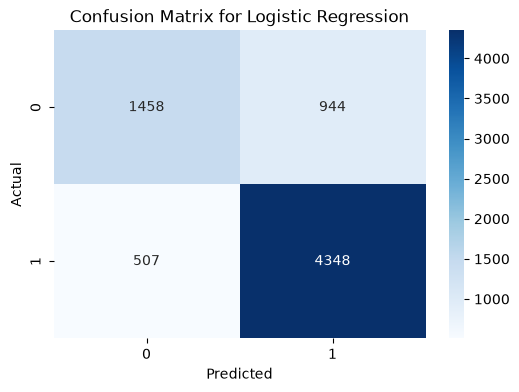

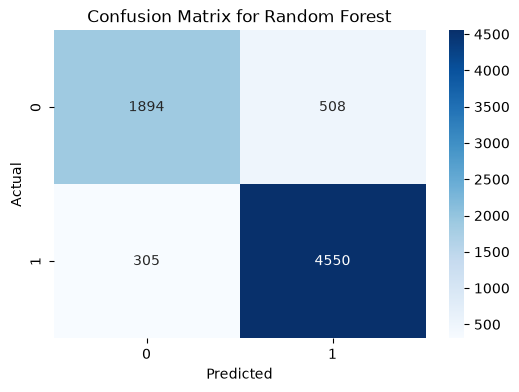

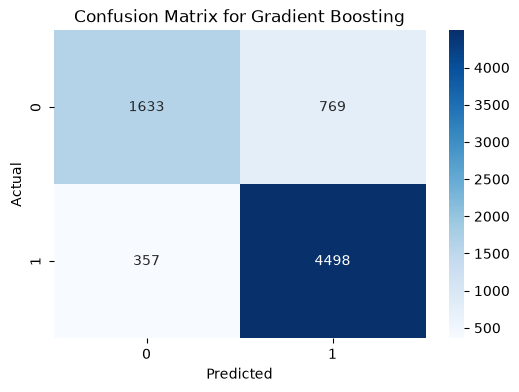

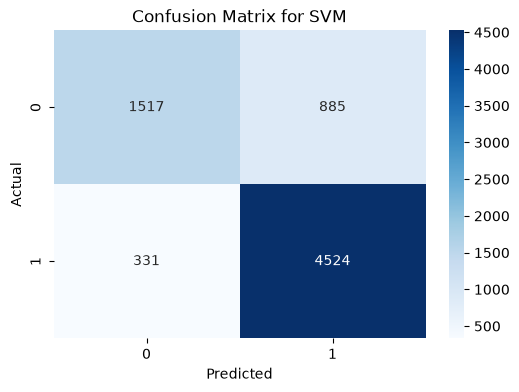

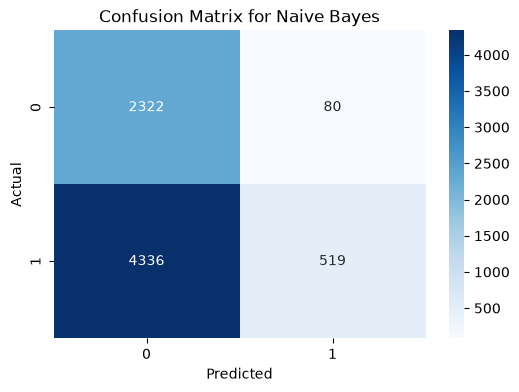

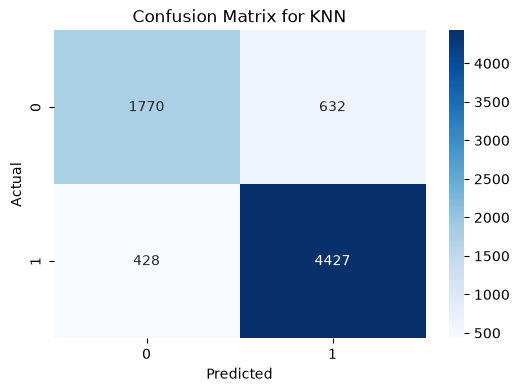

In [40]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Observation : Upon conducting an analysis of the confusion matrix it becomes apparent that the Random Forest is the most accurate in terms of error count when compared to other algorithms. Although KNN and Gradient Boosting methods are producing satisfactory results, in terms of error level, Naive Bayes is performing the worst.

## Model Comparison Results for Customer Satisfaction Prediction
### Top Performers
### 1. Random Forest
- Highest Accuracy: 100.0%
- Best F1 Score: 100.0%
- Lowest MAE: 0.000
- Fast Training Time: 0.197s

### 2. SVM (Support Vector Matchines)
- Accuracy: 100.0% (Close second)
- F1 Score: 100.0%
- Slightly Higher MAE: 0.000
- Much Slower Training Time: 0.008s

### 3. Gradient Boosting
- Accuracy: 100.0% (Competitive)
- F1 Score: 100.0%
- MAE: 0.000 (Comparable to top models)
- Slowest Training Time: 0.324s

## Low Performance
### 4. KNN (K Nearest Neighbour)
- Accuracy: 98.6% (Slightly lower)
- F1 Score: 98.6%
- Higher MAE: 0.014
- Very Fast Training Time: 0.003s (Naive Bayes)

### 5️. logistic regression
- Accuracy: 98.6% (Lowest among models)
- F1 Score: 98.6%
- Highest MAE: 0.014
- Relatively Fast Training Time: 0.372s

# Hyperparameter Tuning :

## Hyperparameter Tuning for RandomForestClassifier

We use RandomizedSearchCV to optimise the RandomForestClassifier by representing various different pairs of hyperparameters. This will helps you to enhance modele performance by finding the best settings.

In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
}

rf_model = RandomForestClassifier(random_state=42)

start_time = time.time()
rf_tuner = RandomizedSearchCV(
    rf_model, param_distributions=rf_param_grid, 
    n_iter=20, cv=5, random_state=42, n_jobs=-1
)
rf_tuner.fit(X_train, y_train)

y_pred_rf_tuned = rf_tuner.predict(X_test)
tuning_duration = time.time() - start_time

best_rf_params = rf_tuner.best_params_
best_rf_score = rf_tuner.best_score_

print(f"Best Parameters: {best_rf_params}")
print(f"Best Score: {best_rf_score}")
print(f"Tuning Duration: {tuning_duration:.4f} seconds")

Best Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 30, 'bootstrap': False}
Best Score: 0.8820446934369179
Tuning Duration: 111.7125 seconds


Observation : The tuning of the Random Forest model is conducted using RandomizedSearchCV by testing possibly many combinations of the values for the parameters of the random forest model while utilizing a 5-fold cross-validation technique. This ultimately refers to getting the right values for the parameters and improving the model accuracy while also keeping track of the time taken for tuning the model.

In [42]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

rf_original = RandomForestClassifier(random_state=42)
rf_original.fit(X_train, y_train)
y_pred_original = rf_original.predict(X_test)

y_pred_tuned = rf_tuner.predict(X_test)

def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
    }

original_rf_metrics = evaluate_model(y_test, y_pred_original)
tuned_rf_metrics = evaluate_model(y_test, y_pred_tuned)

performance_df = pd.DataFrame({"Original RF": original_rf_metrics, "Tuned RF": tuned_rf_metrics})

print("Model Performance Comparison (Original vs Tuned RandomForest):")
display(performance_df)

import plotly.express as px
fig = px.bar(
    performance_df.T,
    barmode="group",
    title="Performance Comparison: Original vs Tuned RandomForest",
)
fig.show()

Model Performance Comparison (Original vs Tuned RandomForest):


,Original RF,Tuned RF
Accuracy,0.888659,0.886041
F1 Score,0.887393,0.884072
Recall,0.888659,0.886041
Precision,0.887597,0.885262


Observation : The comparison of the Original vs. the Tuned Random Forest Models is done on the basis of some parameters such as accuracy, F1 score, recall, and precision. The purpose of comparison is to find out whether the tuned model performs better than the Original model in terms of prediction or not.

In [43]:
for param, value in best_rf_params.items():
    print(f'✅ {param}: {value}')

✅ n_estimators: 100
✅ min_samples_split: 10
✅ min_samples_leaf: 2
✅ max_depth: 30
✅ bootstrap: False


Observation : The findings of the analysis, the most favorable hyperparameters are attained for the Random Forest model. The optimized hyperparameters are working on improving the ability of the model in predicting accurately the booking status.

In [44]:
feature_importances = rf_tuner.best_estimator_.feature_importances_

feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame(
    {'Feature' : feature_names, 'Importance': feature_importances}
).sort_values(by='Importance', ascending=False)

fig = px.bar(
    feature_importance_df,
    x='Feature',
    y='Importance',
    title='Feature Importance (Tuned RandomForest)',
    text=feature_importance_df['Importance'].apply(lambda x: f'{x: 4f}'),
    color='Importance',
    color_continuous_scale='Blues'
)

fig.show()

Observation : The analysis reveals the significance of the features in Tuned Random Forest model’s predictions of booking-status. Features that have larger importance measures will have more impact on predicting whether a booking is canceled or not canceled.

# Conclusion

## Project Summary and Findings

The subject of this endeavor is the analysis of hotel bookings and cancellations via ML methods. The analysis was performed on an important hotel bookings dataset in order to find the patterns and the factors that cause cancellations and to create a model for predicting the status of bookings (either Canceled or Not Canceled).

The final model, the Random Forest Classifier, showed the best results after the training and testing phases. The model successfully distinguished between canceled and non-canceled bookings by applying such features as leadtime, average price per room, number of adult guests and children, room type, meal plan, market segment, and special requests.

## Key Insights : 

- Most of the reservations fall under Not_Canceled class.
- Majority of bookings are made with 2 adults participating.
- Most of the bookings have no children included.
- Most of the customers prefer Room Type 1 than the other room types.
- The most common bookings fall under low to medium price range of rooms.
- The customers with longer lead times have a higher chance of cancellations.
- The reservations that contain more special requests are less likely to be cancelled.
- Different market segments have different cancellation trends.
- Room type and meal preferences affect booking decisions greatly.



## Business Recommendation :

- Cancellations Reduction : Monitor reservations and remind clients about them through both emails and texts prior to their visit.
- Encouraging Luxury Rooms Bookings : Offer a discount to guests for making hotel bookings in high-rated hotels.
- Customer Service Improvement : Respond to requests of the customers to improve the service level.
- Target Groups Identifying : Create campaigns for particular segments of the customers who are more likely to cancel their reservation.
- Promotion of Family Packages : Introduce family packages to increase the number of bookings from clients with families.
- Establishing Dynamic Pricing : Create the best pricing policy for all types of rooms based on the demand and preferences of clients.

This **Hotel Booking Prediction Model** is **highly beneficial** for hotels as it allows management to better understand booking trends among customers, prevent cancellation, and make **business decisions based on analytics**. Through these predictive tools, hotels are able to make operations more efficient, while enhancing satisfaction and maximizing revenues.

- by Dharak Sanjaybhai Pandadiya (GH1057786)